# SigLib — SigLIP2 · LanceDB · SAM3 Retrieval Pipeline

Two phases:
1. **Indexing** — embed all RGB frames of a TUM RGB-D benchmark with `google/siglip2-base-patch16-224` and store vectors in LanceDB.
2. **Retrieval** — embed a text query in the same space, retrieve the top-*k* frames, then run SAM3 to highlight the queried objects.

Images and text share one embedding space (SigLIP2), so a sentence like `"a laptop on a desk"` directly retrieves matching frames — no fine-tuning needed.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [2]:
from transformers import AutoModel, AutoProcessor

SIGLIP_MODEL_ID = "google/siglip2-base-patch16-224"
print(f"Loading {SIGLIP_MODEL_ID} ...")
siglip    = AutoModel.from_pretrained(SIGLIP_MODEL_ID).to(device).eval()
processor = AutoProcessor.from_pretrained(SIGLIP_MODEL_ID)
EMB_DIM   = siglip.config.text_config.hidden_size
print(f"Loaded — embedding dim: {EMB_DIM}")

Loading google/siglip2-base-patch16-224 ...


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Loaded — embedding dim: 768


In [3]:
BATCH_SIZE = 64

@torch.no_grad()
def embed_images(pil_images: list) -> np.ndarray:
    inp  = processor(images=pil_images, return_tensors="pt").to(device)
    vecs = siglip.vision_model(**inp).pooler_output
    return torch.nn.functional.normalize(vecs, dim=-1).cpu().numpy()

@torch.no_grad()
def embed_text(text: str) -> np.ndarray:
    # SigLIP requires padding="max_length" for text inputs
    inp = processor(text=[text], return_tensors="pt", padding="max_length").to(device)
    vec = siglip.text_model(**inp).pooler_output
    return torch.nn.functional.normalize(vec, dim=-1).cpu().numpy()[0]

## Benchmark Selection

Run **exactly one** of the four cells below, then continue.

In [4]:
# ── fr1 / desk ────────────────────────────────────────────────────────────────
DATA_ROOT = "/home/jan/AppliedFoundationModels/data/tum/rgbd_dataset_freiburg1_desk" 

In [5]:
# ── fr1 / room ────────────────────────────────────────────────────────────────
DATA_ROOT = "/home/jan/AppliedFoundationModels/data/tum/rgbd_dataset_freiburg1_room" 

In [6]:
# ── fr2 / desk ────────────────────────────────────────────────────────────────
DATA_ROOT = "/home/jan/AppliedFoundationModels/data/tum/rgbd_dataset_freiburg2_desk" 

In [7]:
# ── fr3 / long_office_household ───────────────────────────────────────────────
DATA_ROOT = "/home/jan/AppliedFoundationModels/data/tum/rgbd_dataset_freiburg3_long_office_household" 

## Indexing

Parse all RGB frames from `rgb.txt`, embed them in batches with SigLIP2, and write vectors to LanceDB.

In [8]:
data_dir  = Path(DATA_ROOT)
benchmark = data_dir.name

def parse_tum_file(path):
    entries = []
    for line in Path(path).read_text().splitlines():
        if line.startswith('#') or not line.strip():
            continue
        parts = line.split()
        entries.append((float(parts[0]), *parts[1:]))
    return entries

rgb_entries = parse_tum_file(data_dir / "rgb.txt")
frames = [{"path": str(data_dir / rel), "ts": ts} for ts, rel in rgb_entries]
print(f"Benchmark : {benchmark}")
print(f"Frames    : {len(frames)}")

Benchmark : rgbd_dataset_freiburg3_long_office_household
Frames    : 2585


In [9]:
import lancedb
import pyarrow as pa

DB_PATH = "/home/jan/AppliedFoundationModels/data/lancedb"
db = lancedb.connect(DB_PATH)

schema = pa.schema([
    pa.field("vector",    pa.list_(pa.float32(), EMB_DIM)),
    pa.field("path",      pa.string()),
    pa.field("timestamp", pa.float64()),
    pa.field("benchmark", pa.string()),
])
table = db.create_table(benchmark, schema=schema, mode="overwrite")
print(f"Created LanceDB table '{benchmark}' at {DB_PATH}")

Created LanceDB table 'rgbd_dataset_freiburg3_long_office_household' at /home/jan/AppliedFoundationModels/data/lancedb


[2026-05-22T17:44:59Z WARN  lance::dataset::write::insert] No existing dataset at /home/jan/AppliedFoundationModels/data/lancedb/rgbd_dataset_freiburg3_long_office_household.lance, it will be created


In [10]:
n_batches = math.ceil(len(frames) / BATCH_SIZE)

for batch_idx in range(n_batches):
    start = batch_idx * BATCH_SIZE
    batch = frames[start : start + BATCH_SIZE]
    imgs  = [Image.open(f["path"]).convert("RGB") for f in batch]
    vecs  = embed_images(imgs)
    table.add([
        {"vector": v.tolist(), "path": f["path"],
         "timestamp": f["ts"], "benchmark": benchmark}
        for v, f in zip(vecs, batch)
    ])
    if (batch_idx + 1) % 5 == 0 or batch_idx == n_batches - 1:
        done = min(start + BATCH_SIZE, len(frames))
        print(f"  {done}/{len(frames)} frames indexed")

print(f"\nDone. Table '{benchmark}' has {table.count_rows()} rows.")

  320/2585 frames indexed
  640/2585 frames indexed
  960/2585 frames indexed
  1280/2585 frames indexed
  1600/2585 frames indexed
  1920/2585 frames indexed
  2240/2585 frames indexed
  2560/2585 frames indexed
  2585/2585 frames indexed

Done. Table 'rgbd_dataset_freiburg3_long_office_household' has 2585 rows.


## Retrieval

Wrap the LanceDB table in an LCEL-compatible LangChain retriever.  
Call `retriever.invoke(query)` or compose it with `|` in a chain.

In [11]:
from typing import Any, List
from langchain_core.retrievers import BaseRetriever
from langchain_core.documents import Document
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from pydantic import ConfigDict

class SigLIPLanceRetriever(BaseRetriever):
    model_config = ConfigDict(arbitrary_types_allowed=True)
    table: Any
    k: int = 5

    def _get_relevant_documents(
        self, query: str, *, run_manager: CallbackManagerForRetrieverRun
    ) -> List[Document]:
        vec  = embed_text(query)
        rows = self.table.search(vec).metric("cosine").limit(self.k).to_list()
        return [
            Document(
                page_content=r["path"],
                metadata={
                    "ts":        r["timestamp"],
                    "distance":  r.get("_distance"),
                    "benchmark": r["benchmark"],
                },
            )
            for r in rows
        ]

retriever = SigLIPLanceRetriever(table=table, k=5)
print("Retriever ready — use retriever.invoke(query) or pipe it in LCEL chains.")

Retriever ready — use retriever.invoke(query) or pipe it in LCEL chains.


Top 5 results for: 'desktop monitor'


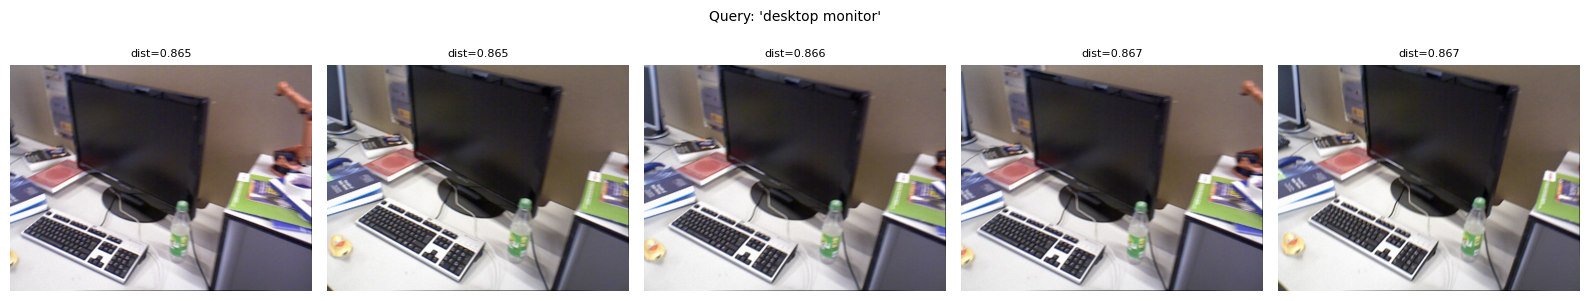

In [ ]:
QUERY = "book"   # ← change to anything

docs = retriever.invoke(QUERY)
print(f"Top {len(docs)} results for: '{QUERY}'")

cols = len(docs)
fig, axes = plt.subplots(1, cols, figsize=(cols * 3.2, 3.2), squeeze=False)
for ax, doc in zip(axes[0], docs):
    img  = Image.open(doc.page_content).convert("RGB")
    dist = doc.metadata.get("distance")
    ax.imshow(img)
    ax.set_title(f"dist={dist:.3f}" if dist is not None else "", fontsize=8)
    ax.axis("off")
plt.suptitle(f"Query: '{QUERY}'", fontsize=10)
plt.tight_layout()
plt.show()

## Object Highlighting with SAM3

SAM3 (`facebook/sam3`) segments objects directly from a text prompt — no bounding-box step needed.  
The same `QUERY` used for retrieval is passed to SAM3 to highlight matching objects in each retrieved frame.

In [16]:
from transformers import Sam3Model, Sam3Processor

SAM_MODEL_ID  = "facebook/sam3"
print(f"Loading {SAM_MODEL_ID} ...")
sam_processor = Sam3Processor.from_pretrained(SAM_MODEL_ID)
sam_model     = Sam3Model.from_pretrained(SAM_MODEL_ID).to(device)
print(f"SAM3 loaded on {device}")

Loading facebook/sam3 ...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

SAM3 loaded on cuda


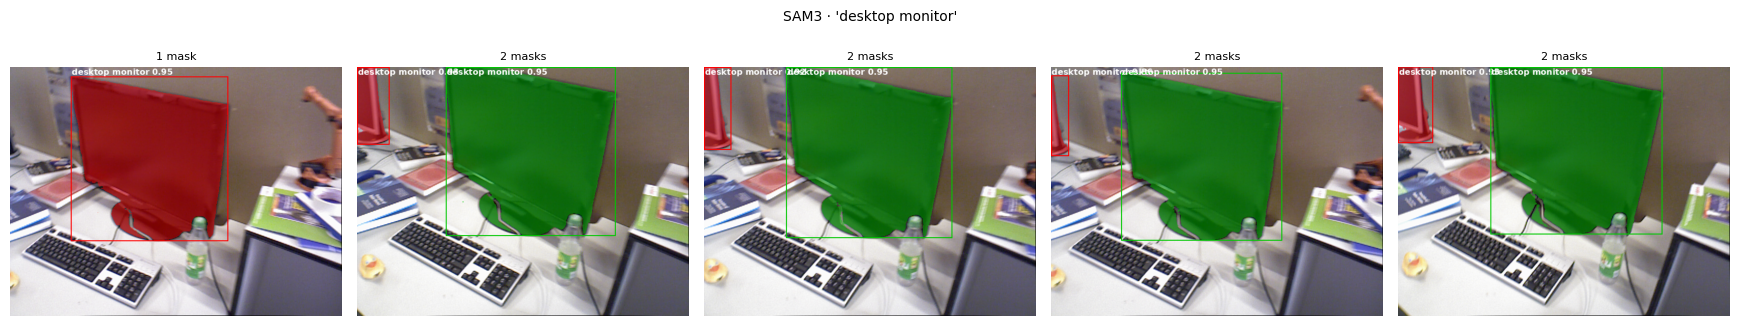

In [17]:
SAM_THRESHOLD = 0.5
COLORS = [(255, 0, 0), (0, 200, 0), (0, 0, 255), (255, 165, 0), (160, 0, 200)]

n    = len(docs)
fig, axes = plt.subplots(1, n, figsize=(n * 3.5, 3.5), squeeze=False)

for ax, doc in zip(axes[0], docs):
    img = Image.open(doc.page_content).convert("RGB")

    inp = sam_processor(images=img, text=QUERY, return_tensors="pt").to(device)
    with torch.no_grad():
        out = sam_model(**inp)
    results = sam_processor.post_process_instance_segmentation(
        out,
        threshold=SAM_THRESHOLD,
        mask_threshold=0.5,
        target_sizes=inp.get("original_sizes").tolist(),
    )[0]

    annotated = img.copy().convert("RGBA")
    for i, mask in enumerate(results["masks"]):
        color   = COLORS[i % len(COLORS)]
        mask_np = mask.cpu().numpy().astype(np.uint8)
        overlay = np.zeros((*mask_np.shape, 4), dtype=np.uint8)
        overlay[mask_np > 0] = [*color, 120]
        annotated = Image.alpha_composite(annotated, Image.fromarray(overlay, mode="RGBA"))

    if len(results["masks"]) > 0:
        draw = ImageDraw.Draw(annotated)
        try:
            font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", size=16)
        except OSError:
            font = ImageFont.load_default()
        for i, (score, box) in enumerate(zip(results["scores"], results["boxes"])):
            color          = COLORS[i % len(COLORS)]
            x0, y0, x1, y1 = box.tolist()
            draw.rectangle([x0, y0, x1, y1], outline=color, width=2)
            caption        = f"{QUERY[:15]} {score:.2f}"
            draw.text((x0 + 2, max(y0 - 20, 0)), caption, fill="white", font=font)

    n_masks = len(results["masks"])
    ax.imshow(np.array(annotated.convert("RGB")))
    ax.set_title(f"{n_masks} mask{'s' if n_masks != 1 else ''}", fontsize=8)
    ax.axis("off")

plt.suptitle(f"SAM3 · '{QUERY}'", fontsize=10)
plt.tight_layout()
plt.show()